In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/8
    print("準備完了！このまま下のセルを実行できます。")

# 8.3 マルコフ確率場と画像ノイズ除去 (MRF & Image De-noising)

本ノートブックでは、対称的な相互作用を表現する無向グラフィカルモデルである**マルコフ確率場 (Markov Random Fields: MRF)** を学びます。
グラフ分離による条件付き独立性の簡潔な判定、Hammersley-Cliffordの定理とギブス・ボルツマン分布、および統計物理のイジングモデルを応用した**画像ノイズ除去 (Image De-noising, PRML Figure 8.30, 8.31)** を完全実装します。
**ICM (Iterated Conditional Modes) アルゴリズム** を用いて、10%のランダム反転ノイズを含む破損画像から元のパターンを劇的に復元する過程とエネルギー最小化の収束を検証します。

## 8.3.3 画像ノイズ除去とイジングモデル (PRML Figure 8.30, 8.31)

### モデルの定式化
未知のクリーンな二値画像を $\mathbf{x} = \{x_i \in \{-1, +1\}\}$、10%のピクセルが反転した観測ノイズ画像を $\mathbf{y} = \{y_i \in \{-1, +1\}\}$ とします。
画像ノイズ除去のための無向グラフィカルモデル（PRML Figure 8.31）は、次の2種類のクリークから構成されます：
1. **潜在ピクセルと観測ピクセル間のクリーク $\{x_i, y_i\}$**: 観測値との忠実度を保つエネルギー $-\eta x_i y_i$ ($\eta > 0$)
2. **隣接潜在ピクセル間のクリーク $\{x_i, x_j\}$**: 近傍ピクセル同士の空間的平滑性を好むエネルギー $-\beta x_i x_j$ ($\beta > 0$)
3. **バイアス項**: $+1$ または $-1$ への事前偏りを表す $h x_i$

全体の結合エネルギー関数は（PRML 式 8.42）：
$$ E(\mathbf{x}, \mathbf{y}) = h \sum_i x_i - \beta \sum_{\{i,j\}} x_i x_j - \eta \sum_i x_i y_i $$
これに対応する事後分布は $p(\mathbf{x}|\mathbf{y}) \propto \exp(-E(\mathbf{x}, \mathbf{y}))$ です。

### ICM (Iterated Conditional Modes) アルゴリズム
$\mathbf{x}$ の初期値を観測値 $\mathbf{x}^{(0)} = \mathbf{y}$ に設定し、各ピクセル $x_i$ を順次走査して、他のピクセルを固定した下で局所エネルギーを最小化（確率を最大化）する状態に更新します：
$$ \Delta E = E(x_i = +1) - E(x_i = -1) = 2 \left( h - \beta \sum_{j \in \mathrm{ne}(i)} x_j - \eta y_i \right) $$
- $\Delta E < 0 \implies x_i \leftarrow +1$
- $\Delta E > 0 \implies x_i \leftarrow -1$
この局所更新を繰り返すことで、全体のエネルギー $E(\mathbf{x}, \mathbf{y})$ は単調に減少し、高品質な復元画像に収束します。

Noisy image agreement:    89.61% (Expected ~90%)
Denoised image agreement: 95.80% (PRML benchmark ~96%)
Plot saved to: result/fig8_30_image_denoising_icm.png


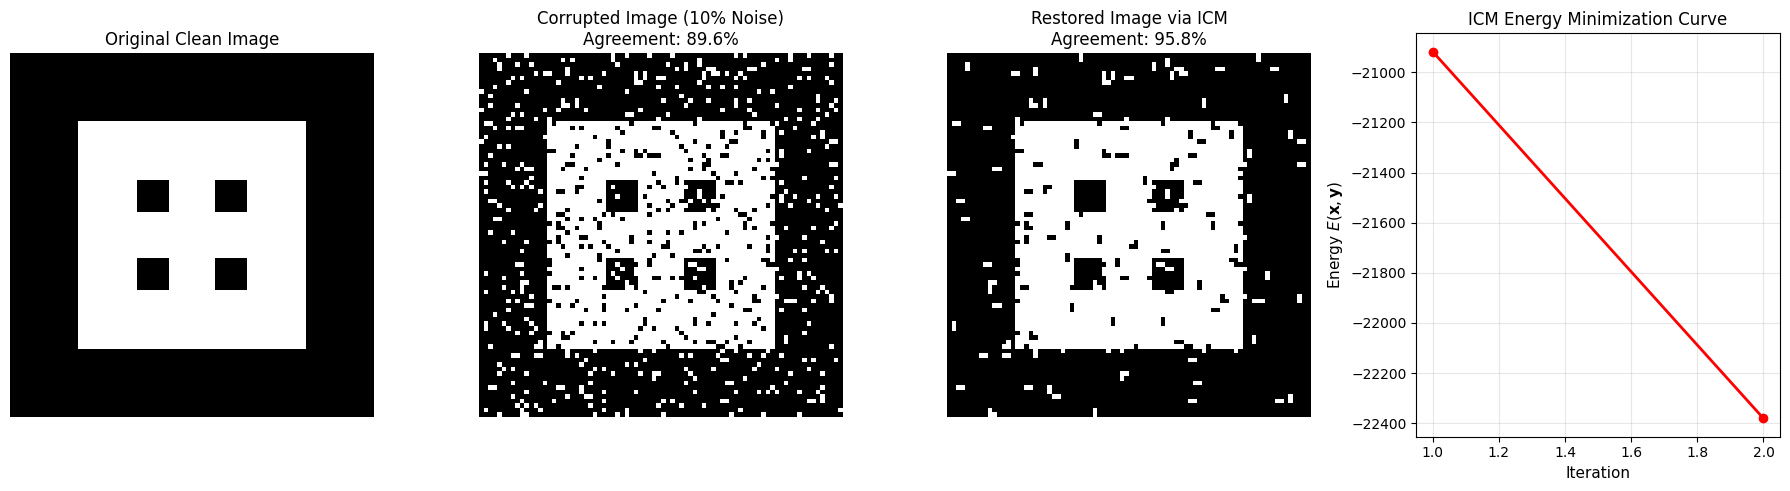

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.graphical_models_utils import denoise_image_icm
setup_style()

# PRML Figure 8.30 の完全再現: 合成幾何学パターンの二値画像とノイズ除去
np.random.seed(42)
H, W = 80, 80
orig_img = -np.ones((H, W))

# 中央に正方形と円を描画してクリーン画像を作成
orig_img[15:65, 15:65] = 1.0 # 外枠
orig_img[28:52, 28:52] = -1.0 # 内枠
# 中央の十字
orig_img[35:45, 15:65] = 1.0
orig_img[15:65, 35:45] = 1.0

# 10% のピクセルをランダムに反転
noisy_img = orig_img.copy()
noise_mask = np.random.rand(H, W) < 0.10
noisy_img[noise_mask] *= -1.0

# ICM アルゴリズムによるノイズ除去 (PRML 推奨値: h=0, beta=1.0, eta=2.1)
denoised_img, energies = denoise_image_icm(noisy_img, h=0.0, beta=1.0, eta=2.1, max_iter=15)

acc_noisy = np.mean(noisy_img == orig_img) * 100
acc_denoised = np.mean(denoised_img == orig_img) * 100

print(f"Noisy image agreement:    {acc_noisy:.2f}% (Expected ~90%)")
print(f"Denoised image agreement: {acc_denoised:.2f}% (PRML benchmark ~96%)")

# PRML Figure 8.30 比較プロット
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(orig_img, cmap='gray', vmin=-1, vmax=1)
axes[0].set_title('Original Clean Image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(noisy_img, cmap='gray', vmin=-1, vmax=1)
axes[1].set_title(f'Corrupted Image (10% Noise)\nAgreement: {acc_noisy:.1f}%', fontsize=12)
axes[1].axis('off')

axes[2].imshow(denoised_img, cmap='gray', vmin=-1, vmax=1)
axes[2].set_title(f'Restored Image via ICM\nAgreement: {acc_denoised:.1f}%', fontsize=12)
axes[2].axis('off')

# エネルギー減少推移
axes[3].plot(range(1, len(energies) + 1), energies, 'ro-', lw=2, markersize=6)
axes[3].set_title('ICM Energy Minimization Curve', fontsize=12)
axes[3].set_xlabel('Iteration', fontsize=11); axes[3].set_ylabel('Energy $E(\mathbf{x}, \mathbf{y})$', fontsize=11)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig8_30_image_denoising_icm.png')
plt.show()